Using font: STIXGeneral


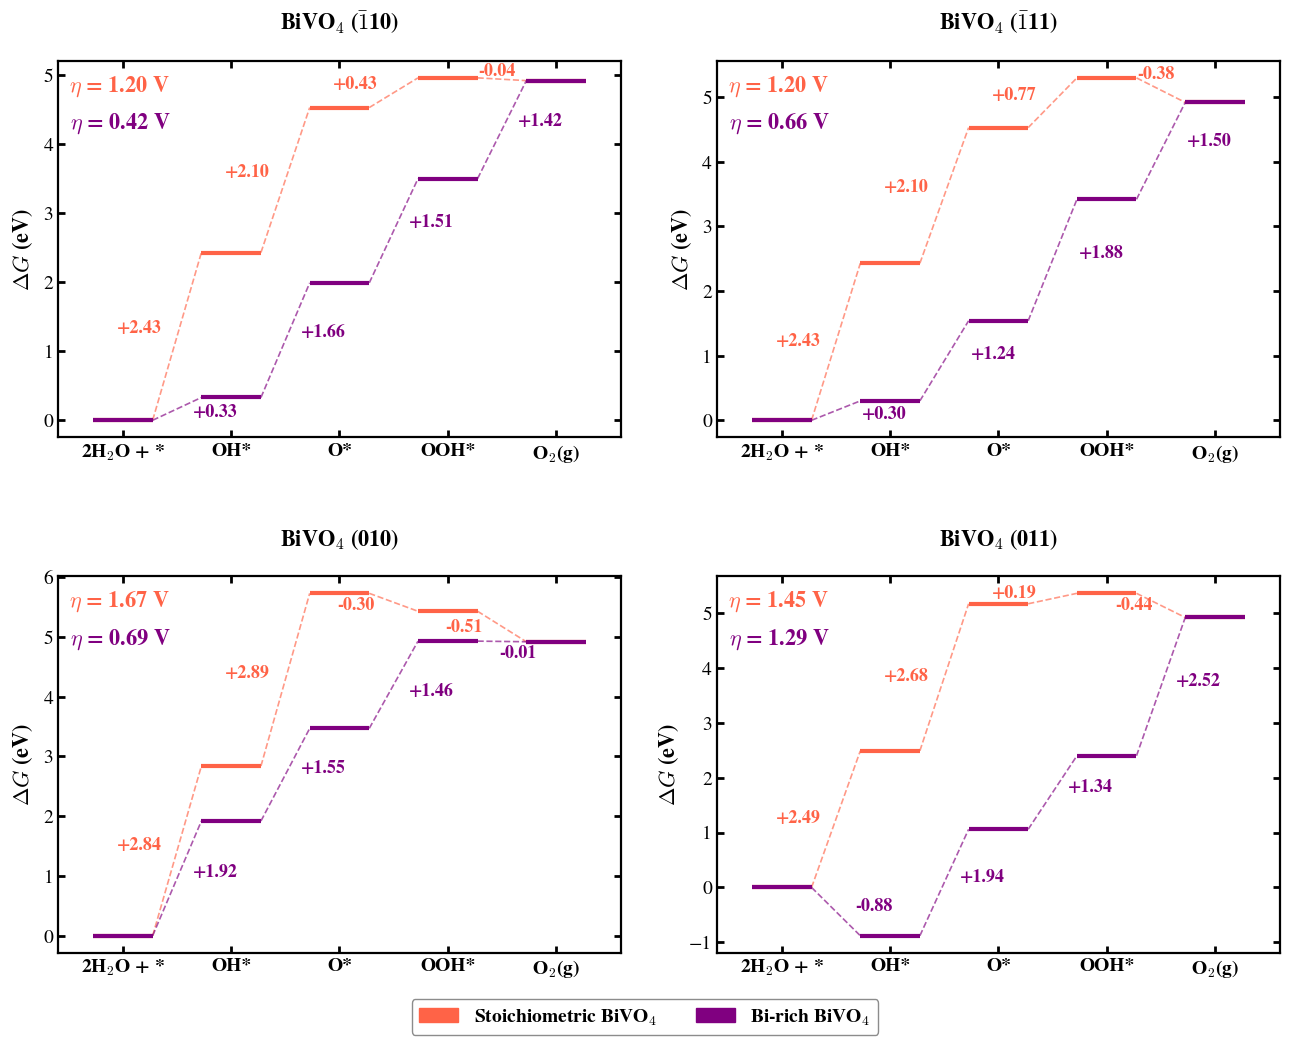

Done


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import matplotlib.font_manager as fm
import numpy as np

# ── Font setup with fallback chain ────────────────────────────────────────────
def get_available_font(candidates):
    available = set(f.name for f in fm.fontManager.ttflist)
    for font in candidates:
        if font in available:
            print(f"Using font: {font}")
            return font
    return None

preferred_fonts = [
    "Latin Modern Roman",
    "CMU Serif",
    "STIXTwo Text",
    "STIXGeneral",
    "DejaVu Serif",
]

chosen = get_available_font(preferred_fonts)
if chosen:
    mpl.rcParams['font.family'] = chosen

mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['axes.linewidth']   = 1.4

# ── Data ──────────────────────────────────────────────────────────────────────
data = {
    "011_sto":     {"dG": [0.00,  2.49, 5.17, 5.36, 4.92], "eta": 1.45},
    "011_Bi-rich": {"dG": [0.00, -0.88, 1.06, 2.40, 4.92], "eta": 1.29},
    "010_sto":     {"dG": [0.00,  2.84, 5.73, 5.43, 4.92], "eta": 1.67},
    "010_Bi-rich": {"dG": [0.00,  1.92, 3.47, 4.93, 4.92], "eta": 0.69},
    "110_sto":     {"dG": [0.00,  2.43, 4.53, 4.96, 4.92], "eta": 1.20},
    "110_Bi-rich": {"dG": [0.00,  0.33, 1.99, 3.50, 4.92], "eta": 0.42},
    "111_sto":     {"dG": [0.00,  2.43, 4.53, 5.30, 4.92], "eta": 1.20},
    "111_Bi-rich": {"dG": [0.00,  0.30, 1.54, 3.42, 4.92], "eta": 0.66},
}

# ── Manual annotation offsets (dx, dy) ────────────────────────────────────────
offsets = {
    "011_sto":     [(-0.35, 0.02), (-0.35, 0.02), (-0.35, 0.10), (-0.25, 0.005)],
    "011_Bi-rich": [( 0.35, 0.10), ( 0.35, 0.10), ( 0.35, 0.10), ( 0.35, 0.10)],
    "010_sto":     [(-0.35, 0.10), (-0.35, 0.10), (-0.35, -0.05),(-0.35, -0.02)],
    "010_Bi-rich": [( 0.35, 0.10), ( 0.35, 0.10), ( 0.35, -0.10), ( 0.15, -0.20)],
    "110_sto":     [(-0.35, 0.12), (-0.35, 0.12), (-0.35, 0.12), (-0.05, 0.12)],
    "110_Bi-rich": [( 0.35, -0.05), ( 0.35, 0.12), ( 0.35, 0.12), ( 0.35, 0.12)],
    "111_sto":     [(-0.35, 0.01), (-0.35, 0.12), (-0.35, 0.12), (-0.05, 0.25)],
    "111_Bi-rich": [( 0.45, -0.05), ( 0.45, 0.10), ( 0.45, 0.10), ( 0.45, 0.15)],
}

labels       = ["2H$_2$O + *", "OH*", "O*", "OOH*", "O$_2$(g)"]
x_pos        = [0, 1, 2, 3, 4]
bar_w        = 0.55

# ── Updated order: (̄110) > (̄111) > (010) > (011) ───────────────────────────
pairs = [
    ("110_sto", "110_Bi-rich"),   # top-left
    ("111_sto", "111_Bi-rich"),   # top-right
    ("010_sto", "010_Bi-rich"),   # bottom-left
    ("011_sto", "011_Bi-rich"),   # bottom-right
]

# ── Corrected facet labels with \bar notation ─────────────────────────────────
facet_labels = [
    r"($\bar1$10)",
    r"($\bar{1}$11)",
    r"(010)",
    r"(011)",
]

sto_color = "tomato"
bi_color  = "purple"

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=False)
axes = axes.flatten()

for ax, (sto_key, bi_key), flabel in zip(axes, pairs, facet_labels):
    for key, color, sign in [(sto_key, sto_color, +1), (bi_key, bi_color, -1)]:
        dG  = data[key]["dG"]
        eta = data[key]["eta"]
        off = offsets[key]

        # Horizontal level bars
        for i, g in enumerate(dG):
            ax.hlines(g, x_pos[i] - bar_w/2, x_pos[i] + bar_w/2,
                      colors=color, linewidths=3, zorder=4)

        # Dashed connectors
        for i in range(len(dG) - 1):
            ax.plot([x_pos[i] + bar_w/2, x_pos[i+1] - bar_w/2],
                    [dG[i], dG[i+1]],
                    color=color, linestyle="--", linewidth=1.2,
                    alpha=0.65, zorder=2)

        # ΔG step annotations
        for i in range(len(dG) - 1):
            delta  = dG[i+1] - dG[i]
            mid_x  = (x_pos[i] + bar_w/2 + x_pos[i+1] - bar_w/2) / 2
            mid_y  = (dG[i] + dG[i+1]) / 2
            dx, dy = off[i]
            ax.text(mid_x + dx, mid_y + dy,
                    f"{delta:+.2f}",
                    ha="center", va="center",
                    fontsize=13, color=color, fontweight="bold")

        # Overpotential labels
        if sign == +1:
            ax.text(0.02, 0.90, f"$\\eta$ = {eta:.2f} V",
                    transform=ax.transAxes, ha="left", va="bottom",
                    fontsize=16, color=color, fontweight="bold")
        else:
            ax.text(0.20, 0.80, f"$\\eta$ = {eta:.2f} V",
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=16, color=color, fontweight="bold")

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=24, fontweight="bold")
    ax.set_ylabel(r"$\Delta G$ (eV)", fontsize=16, fontweight="bold", labelpad=6)
    ax.set_xlim(-0.6, 4.6)
    ax.set_title(f"BiVO$_4$ {flabel}", fontsize=16, fontweight="bold", pad=22)
    ax.tick_params(axis="both", labelsize=14, width=2, length=5,
                   direction="in", top=True, right=True)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.6)

# ── Shared legend ─────────────────────────────────────────────────────────────
sto_patch = mpatches.Patch(color=sto_color, label="Stoichiometric BiVO$_4$")
bi_patch  = mpatches.Patch(color=bi_color,  label="Bi-rich BiVO$_4$")
fig.legend(handles=[sto_patch, bi_patch],
           loc="lower center", ncol=2,
           prop={"weight": "bold", "size": 14},
           frameon=True, edgecolor="gray", framealpha=0.9,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(h_pad=4.5, w_pad=2.5)
plt.savefig("/Users/atishghosh/Documents/OER_facets_free_energy3.png",
            dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
print("Done")